# Dermoscopic Lesion Segmentation: Comparing Three Classical Methods

This notebook walks through the full pipeline of the project and compares three
non-learning segmentation methods on dermoscopic images of skin lesions:

1. **Multi-channel Otsu** thresholding, refined by a Chan-Vese active contour
2. **LBP Clustering**, after Pereira et al. (2020)
3. **Statistical Region Merging**, after Celebi et al. (2008)

All the algorithms live in the `dermoseg` package under `src/`. This notebook
only calls them and draws the results, so the code shown here stays readable
and the notebook cannot drift away from what the benchmark script runs.

## Setup

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from dermoseg import postprocessing, visualization as viz
from dermoseg.data import iter_samples, load_sample
from dermoseg.pipeline import METHODS, run_all_methods
from dermoseg.preprocessing import preprocess_with_mask
from dermoseg.segmentation import lbp, otsu, region_merging

plt.rcParams["figure.dpi"] = 90
print("methods:", ", ".join(METHODS))

methods: Otsu, LBP, SRM


## 1. The dataset

Twenty dermoscopic images from the ISIC archive, ten melanomas and ten nevi,
each paired with an expert-drawn segmentation mask used as ground truth.

The pairing is what makes the comparison quantitative: every predicted mask is
scored against the expert's with the Dice coefficient.

20 images
melanoma    10
nevus       10


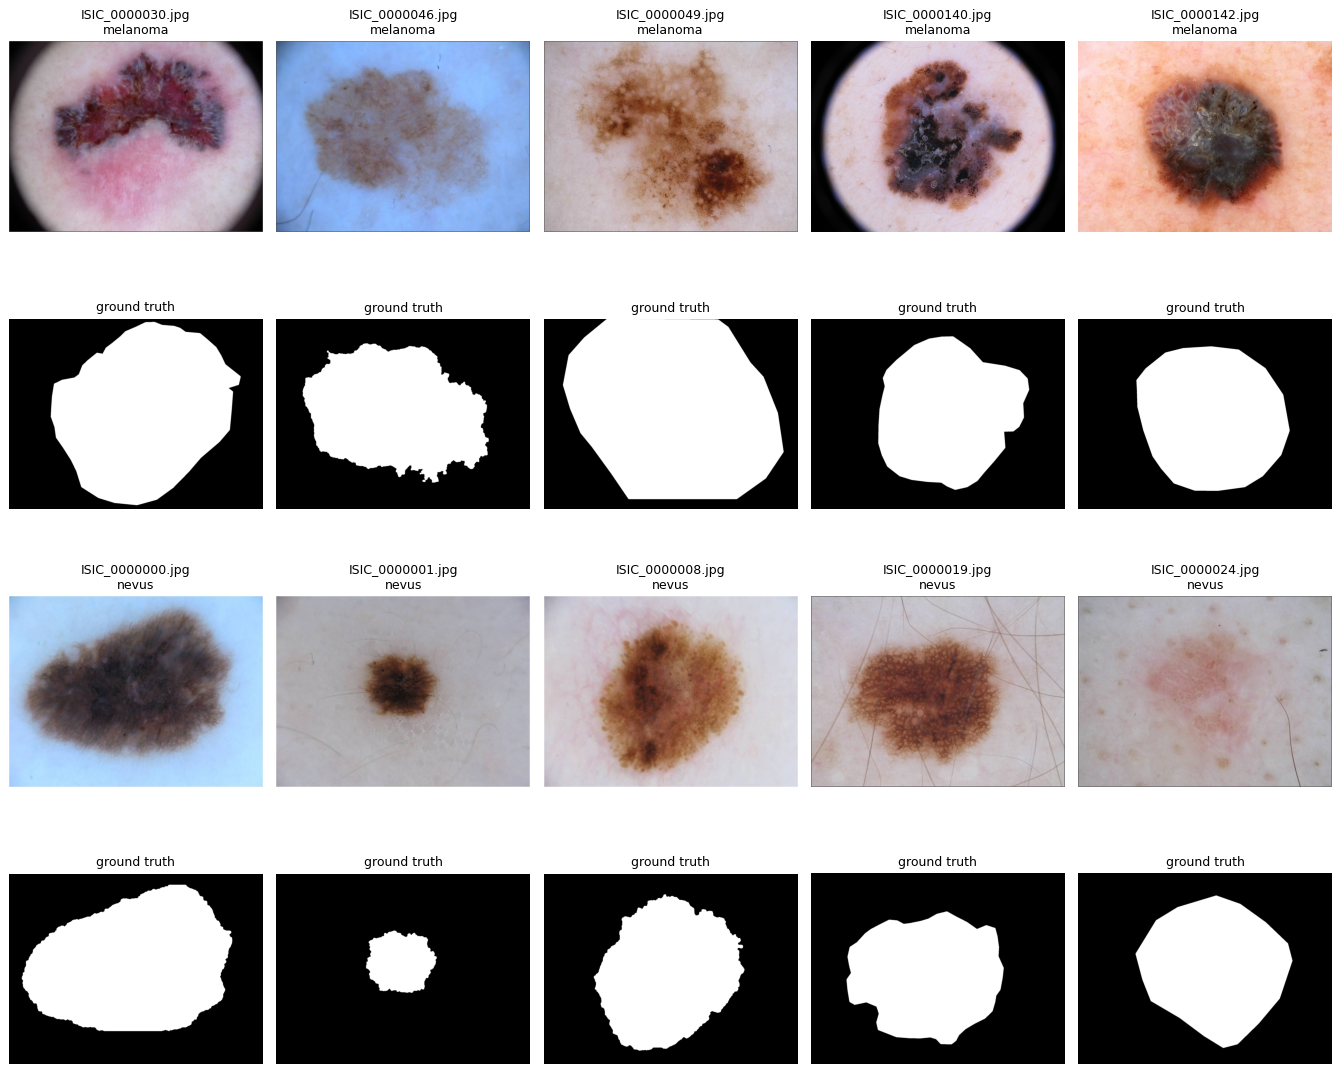

In [2]:
samples = list(iter_samples())
print(f"{len(samples)} images")
print(pd.Series([s.category for s in samples]).value_counts().to_string())

figure = viz.plot_dataset_overview(samples[:5] + samples[10:15])
plt.show()

## 2. Preprocessing

Two artefacts have to go before any segmenter sees the image.

**The dermoscope frame.** The instrument images the skin through a circular
lens, so the corners of many ISIC images are black. No intensity-based method
can tell a black corner from a dark lesion, so the disc is detected and the
outside is whitened and cropped away.

**Hair.** Dark elongated structures crossing the lesion border break both the
thresholds and the region merging. Following DullRazor, hairs are found by
grayscale closing with elongated structuring elements (a closing with an
element wider than a hair erases it, so the difference reveals it), then
inpainted from the surrounding skin.

Images with little hair are left untouched: inpainting a clean image only
blurs the border we are trying to find.

One honest caveat: this detector flags any dark structure narrower than its
structuring elements, and the dark, textured interior of a lesion qualifies.
On two hairless images here (ISIC_0000140, used below, and ISIC_0000142) it
passes the coverage gate on lesion texture alone, and "removes hair" from
inside the lesion. The small coloured shards visible inside the lesion below
come from that.

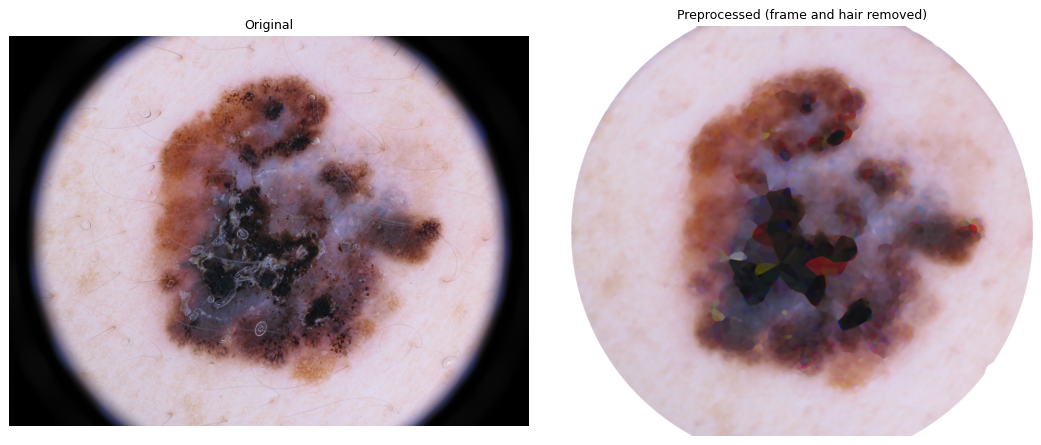

original (2112, 2816, 3) -> preprocessed (2112, 2379, 3)
valid (inside the dermoscope disc): 84.5% of pixels


In [3]:
sample = load_sample(ROOT / "data" / "melanoma" / "ISIC_0000140.jpg")
image, valid_mask = preprocess_with_mask(sample.image)

figure = viz.plot_preprocessing(sample.image, image)
plt.show()

print(f"original {sample.image.shape} -> preprocessed {image.shape}")
print(f"valid (inside the dermoscope disc): {valid_mask.mean():.1%} of pixels")

## 3. Method 1: Multi-channel Otsu

Otsu's threshold is computed independently on R, G and B. A lesion is darker
than skin in all three, but blue carries the strongest melanin contrast, so
the channels are combined as `(R and G) or B`: a pixel is lesion when red
*and* green agree, or when blue alone is confident.

That mask has ragged borders, so it seeds a Chan-Vese active contour which
relaxes onto the real intensity boundary.

As with LBP below, the thresholds are computed over the valid area only, so
the whitened frame corners cannot pull them (Section 7).

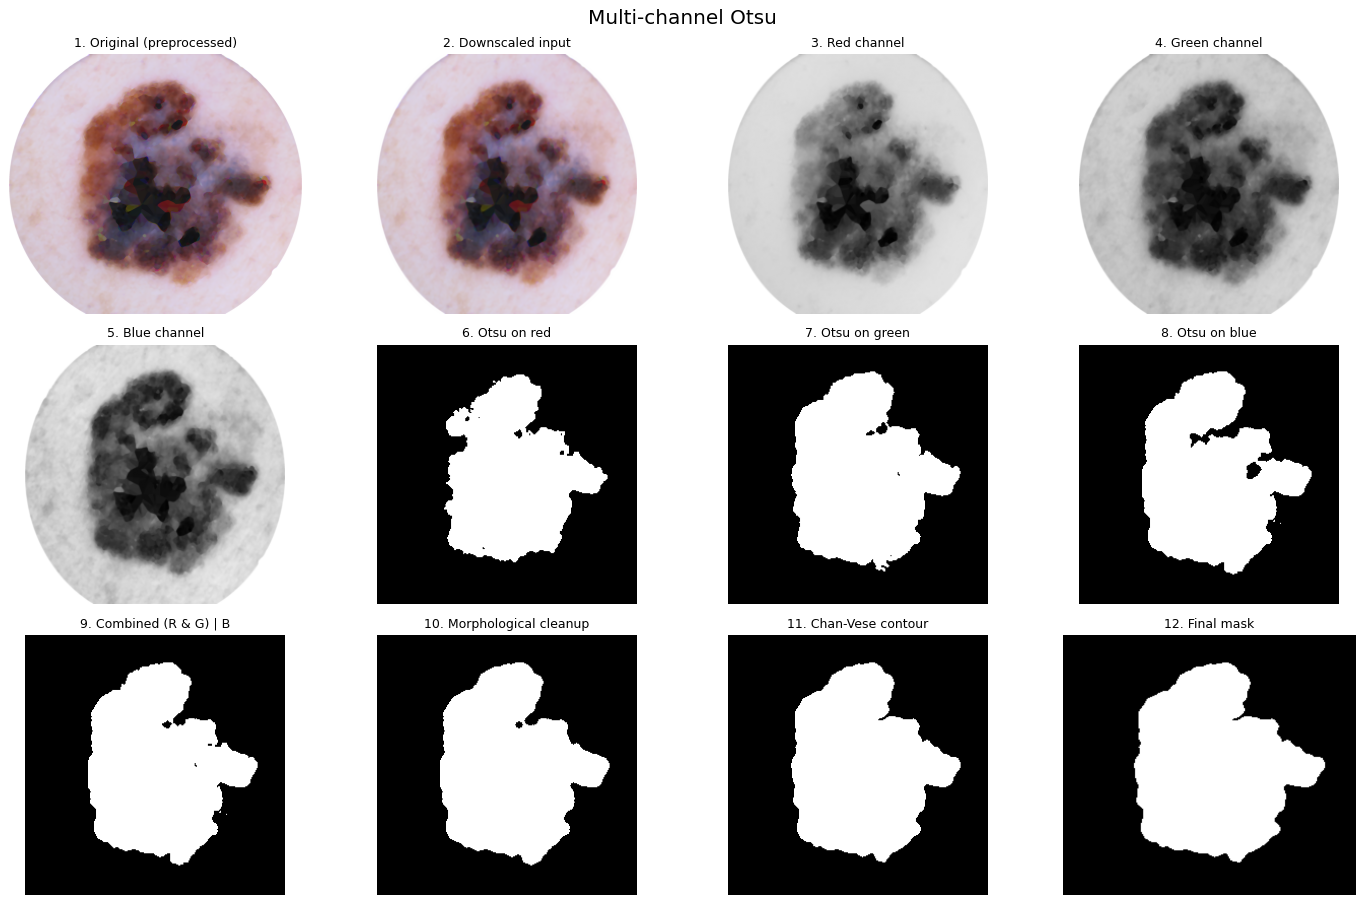

{'red': 0.604, 'green': 0.519, 'blue': 0.552}


In [4]:
result_otsu = otsu.segment(image, valid_mask=valid_mask)
figure = viz.plot_pipeline(result_otsu, title="Multi-channel Otsu", original=image)
plt.show()

print({name: round(value, 3) for name, value in result_otsu.info["thresholds"].items()})

## 4. Method 2: LBP Clustering

The assumption is textural: lesion skin is busier than healthy skin.

Local Binary Patterns with P=8 neighbours at radius R=1 label each pixel by the
sign pattern of its neighbourhood. The flat patterns (code 0, and the eight
powers of two, meaning a single brighter neighbour) mark smooth skin;
everything else marks texture. Binarising on that subset gives a texture map,
which is smoothed into a continuous field L.

L is then stacked with the luminance Y into a synthetic image `[L, Y, L]` and
converted to CIE L\*a\*b\*. Clustering the (a\*, b\*) chromaticity of *that*
image separates lesion from skin, and the **pinkness** score
`max(a*, 0) - min(b*, 0)` picks which of the two clusters is the lesion, with
no training and no labels.

One caveat specific to cropped images: the whitened corners turn pure green in
the pseudo-RGB, an extreme in (a\*, b\*). Left in, they would capture a cluster
outright and k-means would separate disc from corners rather than lesion from
skin, so the fit is restricted to the valid area.

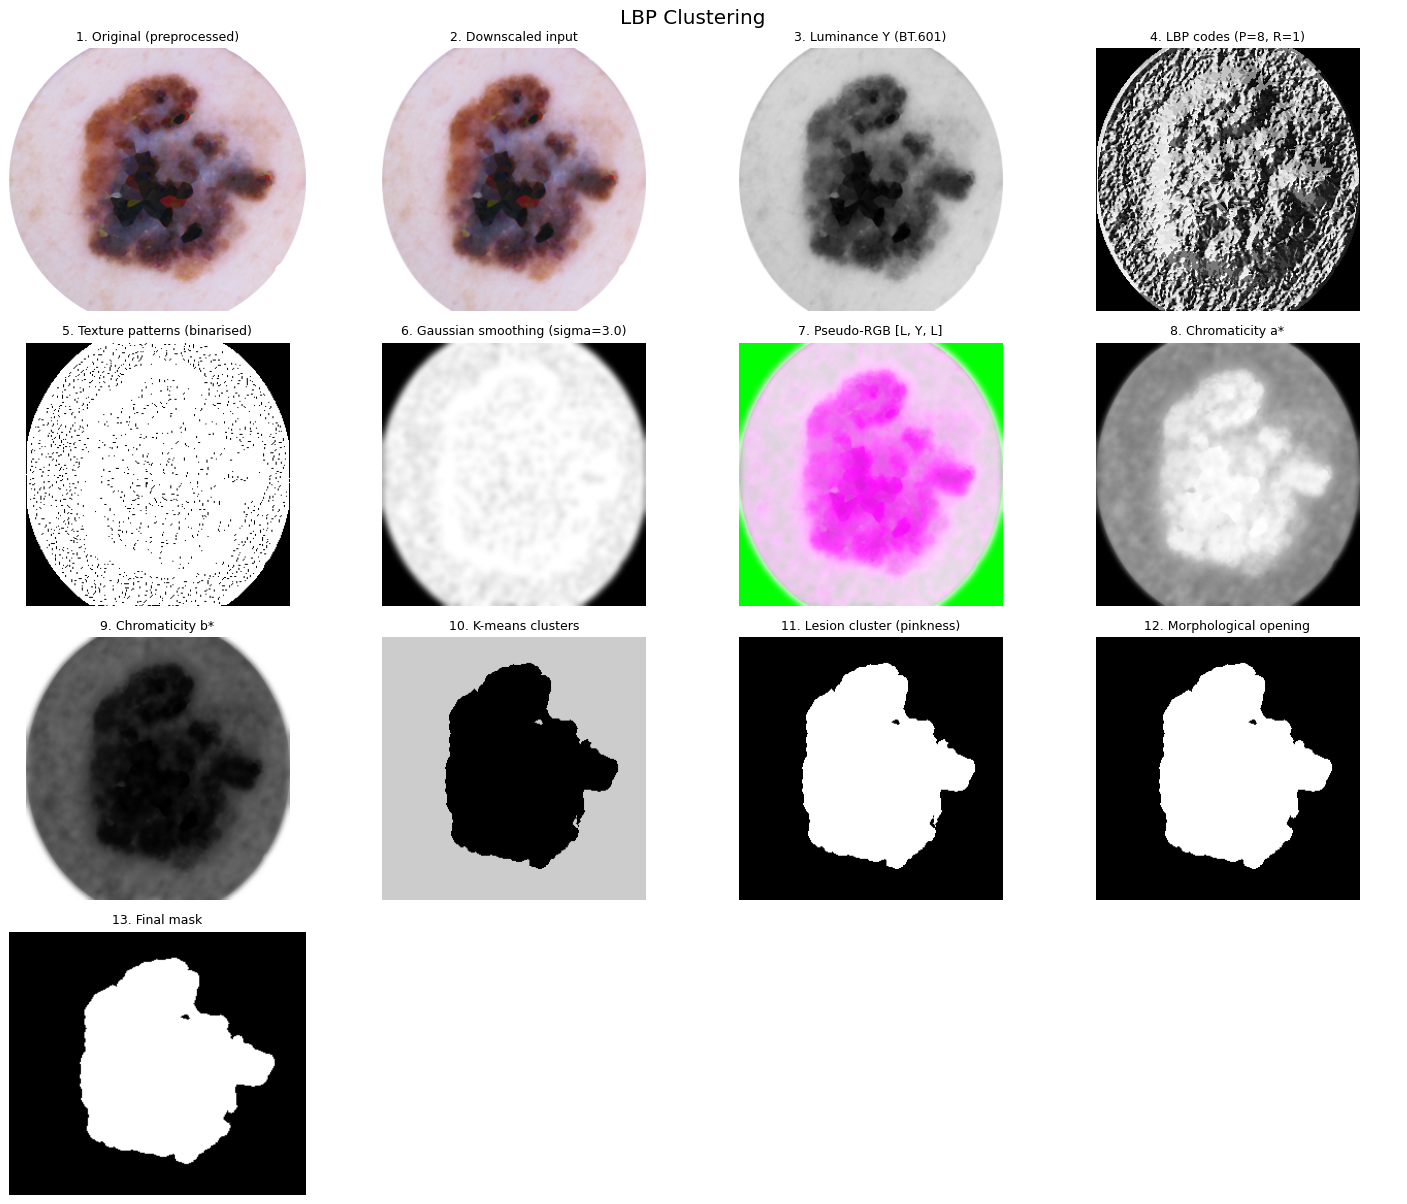

pinkness per cluster: [126.6, 31.0] -> lesion is cluster 0


In [5]:
result_lbp = lbp.segment(image, sigma=3.0, valid_mask=valid_mask)
figure = viz.plot_pipeline(result_lbp, title="LBP Clustering", original=image)
plt.show()

scores = [round(value, 1) for value in result_lbp.info["pinkness_scores"]]
print(f"pinkness per cluster: {scores} -> lesion is cluster {result_lbp.info['lesion_cluster']}")

## 5. Method 3: Statistical Region Merging

SRM visits pairs of neighbouring pixels in order of increasing intensity
difference and merges them through a union-find structure whenever their
region means differ by less than a statistical bound. The bound tightens as
regions grow, so early merges are easy and late merges must be well supported.
The Q parameter sets how permissive it is: smaller Q, fewer and larger regions.

That produces an over-segmentation, not a lesion. Regions are then scored on
three criteria (darkness relative to skin, centrality, and saturation above
skin), and the best region is merged with any close runner-up, because lesions
are routinely split across several regions.

The skin reference comes from a band along the image border, which on an
unframed image is mostly healthy skin. On a framed image it mostly runs
through the whitened corners instead (Section 7). No
training required.

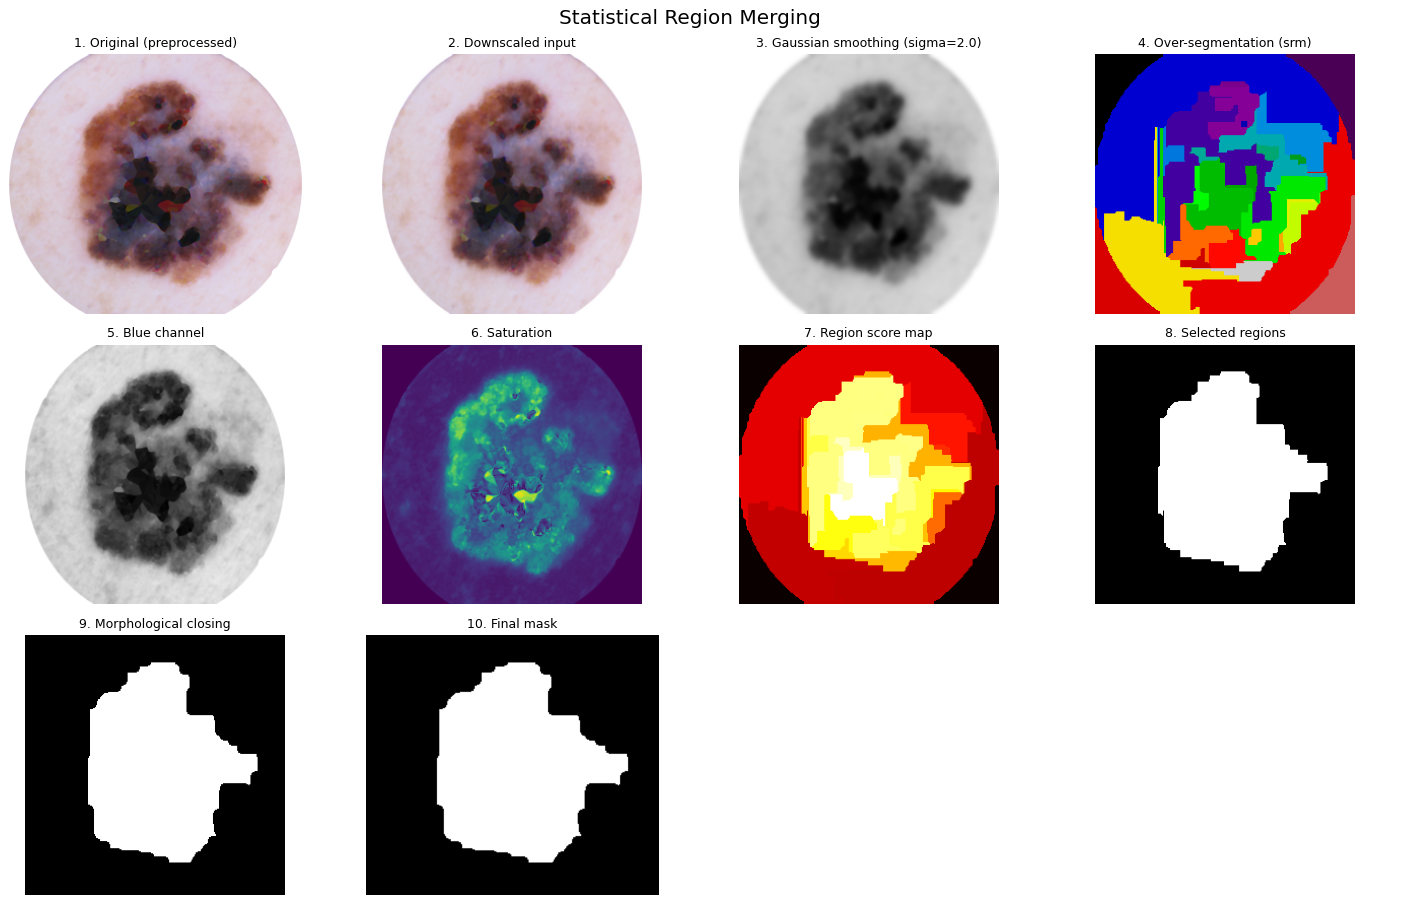

33 regions at Q=25.0


In [6]:
result_srm = region_merging.segment(image, scale=25.0, gaussian_sigma=2.0, backend="srm")
figure = viz.plot_pipeline(result_srm, title="Statistical Region Merging", original=image)
plt.show()

print(f"{result_srm.info['n_regions']} regions at Q={result_srm.info['scale']}")

### Felzenszwalb as a reference point

Felzenszwalb's graph-based segmentation solves a similar over-segmentation
problem much faster. It is a *different* algorithm, so it is reported
separately and never labelled SRM.

In [7]:
result_fz = region_merging.segment(image, scale=25.0, gaussian_sigma=2.0, backend="felzenszwalb")
print(f"SRM          {result_srm.info['n_regions']:3d} regions")
print(f"Felzenszwalb {result_fz.info['n_regions']:3d} regions")

SRM           33 regions
Felzenszwalb  35 regions


## 6. Comparing the three on one image

Each raw mask goes through the same post-processing (hole filling, an
inversion guard, and a convex hull that ignores distant specks of noise), so
the three are compared on equal terms and only the segmentation itself differs.

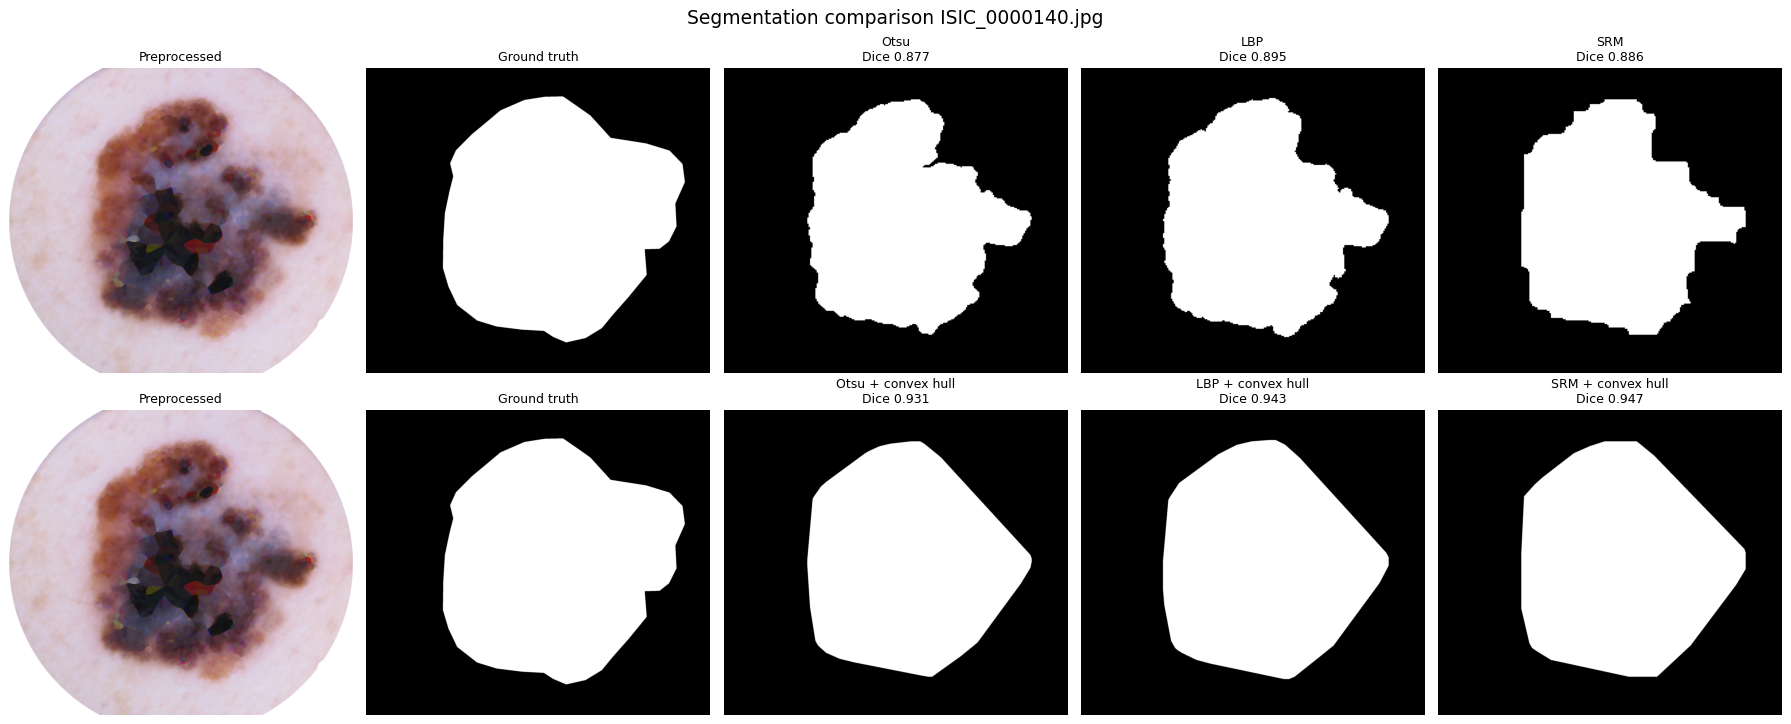

Otsu  Dice 0.877   with convex hull 0.931
LBP   Dice 0.895   with convex hull 0.943
SRM   Dice 0.886   with convex hull 0.947


In [8]:
outcome = run_all_methods(sample, keep_results=True)

figure = viz.plot_comparison(
    outcome.preprocessed,
    outcome.ground_truth,
    outcome.masks,
    hulls=outcome.hulls,
    scores=outcome.scores,
    name=sample.name,
)
plt.show()

for method in METHODS:
    raw = outcome.scores[method]
    hull = outcome.scores[f"{method}_Hull"]
    print(f"{method:<5} Dice {raw:.3f}   with convex hull {hull:.3f}")

## 7. What an audit of the pipeline found

Every step above rests on an assumption, and an assumption can silently stop
holding. An audit of this code found the cases below. The first three are
demonstrated after the list, with their numbers computed live.

- **Scoring of framed images.** Frame removal crops a framed image, but its
  ground truth was resized to the cropped shape instead of being cropped with
  it, so prediction and truth no longer covered the same pixels. Fixed (7.1).
- **`clean_mask` guessed the dermoscope disc** from the image's shape, on
  every image, deleting lesion pixels outside that guess even on the images
  that have no frame at all. It now clips to the real valid area. Fixed (7.2).
- **The convex hull's satellite filter** measured "close" relative to the
  lesion's own radius, a reach that can exceed the image on a large lesion,
  and kept any large enough region whatever its distance. Distance alone now
  decides, relative to the image diagonal. Fixed (7.3).
- **The whitened frame corners** were read as real data by Otsu's thresholds
  and by SRM's skin reference, as they had been by LBP before it was guarded.
  Otsu now ignores them. The same change makes SRM worse, because its scoring
  weights were tuned around the biased reference, so for SRM it is documented
  in `region_merging.segment` rather than applied.
- **The hair-removal gate** summed a raw intensity difference instead of
  counting pixels. It now counts pixels. Fixed.
- **An inversion guard** flipped any mask covering more than 60% of the valid
  area, assuming it had selected skin. No segmenter output here ever came
  close to that, while two real lesions are larger, so it could only damage a
  correct mask. Removed.
- **Colour smoothing** blurred across the channel axis, mixing red into blue.
  SRM now smooths the grayscale image, and Felzenszwalb each channel
  separately. Fixed.

One earlier claim did not survive the audit: two diagonal structuring
elements were added to hair detection on the belief that the axis-aligned
ones missed diagonal hairs. They do not miss them. Every element is 10 px
wide, so a closing with any of them erases any thinner hair, whatever its
orientation. The diagonals only add more of the lesion's own dark texture,
which is this detector's real weakness (Section 2).

### 7.1 Framed images were scored against a stretched ground truth

Frame removal crops a framed image to the dermoscope disc's bounding box. The
ground truth was not cropped with it: `dice_score` saw the two shapes differ
and resized the full-size ground truth to the cropped shape, squeezing it
sideways. Prediction and truth no longer described the same pixels, and
nothing raised an error.

The cleanest measure is to score a perfect prediction, the ground truth
itself correctly cropped, which should score exactly 1. The pipeline now
crops the ground truth with `dermoscope_crop_box`, the same box frame removal
uses, and `tests/test_pipeline.py` pins it.

Dice of a perfect prediction on each framed image
  ISIC_0000030.jpg: 1503 -> 1403 px wide   old scoring 0.965   fixed 1.000


  ISIC_0000140.jpg: 2816 -> 2379 px wide   old scoring 0.915   fixed 1.000
  ISIC_0000045.jpg: 1504 -> 1275 px wide   old scoring 0.916   fixed 1.000


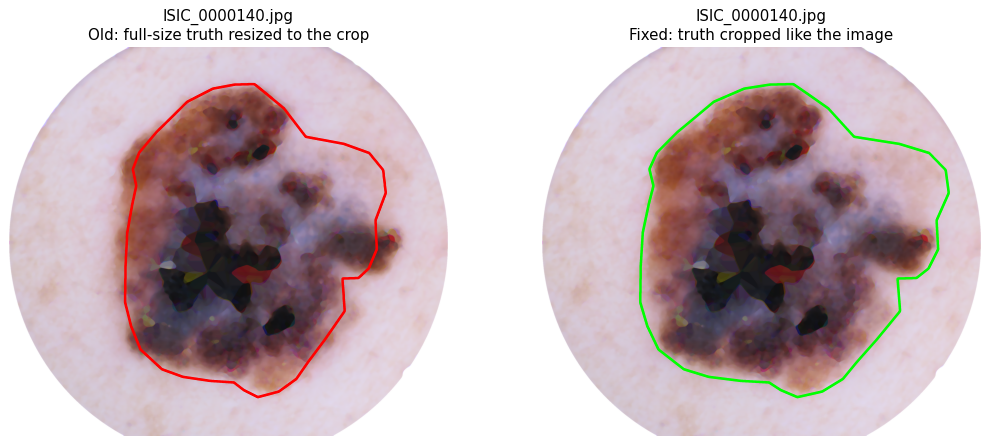

In [9]:
from skimage.transform import resize

from dermoseg.metrics import dice_score
from dermoseg.preprocessing import dermoscope_crop_box

print("Dice of a perfect prediction on each framed image")
for framed_path in ["melanoma/ISIC_0000030", "melanoma/ISIC_0000140", "nevus/ISIC_0000045"]:
    framed_sample = load_sample(ROOT / "data" / f"{framed_path}.jpg")
    perfect = framed_sample.ground_truth[dermoscope_crop_box(framed_sample.image)]
    old = dice_score(perfect, framed_sample.ground_truth)  # old: full-size truth, resized by dice_score
    print(f"  {framed_sample.name}: {framed_sample.image.shape[1]} -> {perfect.shape[1]} px wide"
          f"   old scoring {old:.3f}   fixed {dice_score(perfect, perfect):.3f}")

# outcome is ISIC_0000140, from Section 6.
stretched = resize(sample.ground_truth > 0, outcome.ground_truth.shape, order=0, anti_aliasing=False)
figure, axes = plt.subplots(1, 2, figsize=(12, 5))
for axis, truth, colour, title in (
    (axes[0], stretched, "red", "Old: full-size truth resized to the crop"),
    (axes[1], outcome.ground_truth, "lime", "Fixed: truth cropped like the image"),
):
    axis.imshow(outcome.preprocessed)
    axis.contour(truth, [0.5], colors=colour, linewidths=2)
    axis.set_title(f"{sample.name}\n{title}")
    axis.axis("off")
figure.tight_layout()
plt.show()


### 7.2 `clean_mask` was clipping to a guessed disc, not the real valid area

`clean_mask` is meant to drop everything outside the dermoscope disc. The
buggy version guessed that disc from the image's aspect ratio, on *every*
image, including the seventeen of twenty that preprocessing found to have no
frame at all. On those, the guess is pure fiction, and any lesion pixel
outside it is deleted.

`ISIC_0000049` has no frame, and its lesion reaches close to the top-left
corner.

ISIC_0000049.jpg has no frame, so the real valid area is the whole image.
Old clean_mask (guessed disc) erased 20.4% of the true lesion.
Fixed clean_mask (real valid area) erases 0.0%.


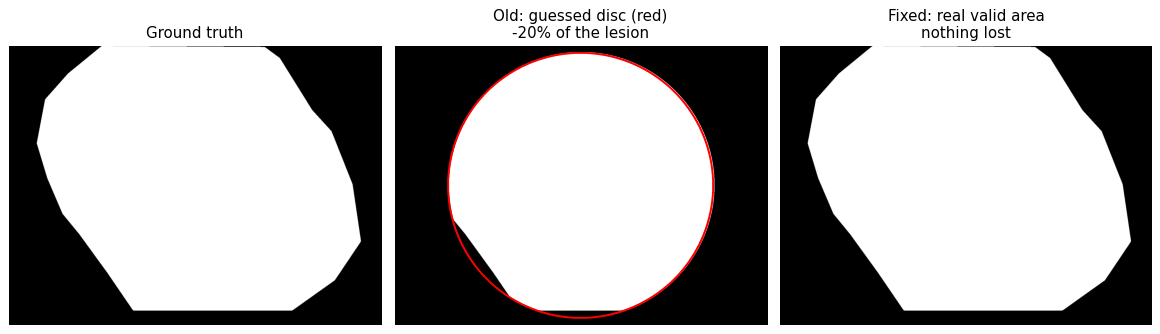

In [10]:
import numpy as np


def guessed_disc_of(mask):
    """The disc clean_mask used to invent from the array shape, before the fix."""
    height, width = mask.shape
    grid_y, grid_x = np.ogrid[:height, :width]
    centre_y, centre_x = height // 2, width // 2
    return (grid_x - centre_x) ** 2 + (grid_y - centre_y) ** 2 <= (
        min(height, width) // 2 * 0.95
    ) ** 2


leak_sample = load_sample(ROOT / "data" / "melanoma" / "ISIC_0000049.jpg")
truth = leak_sample.ground_truth.astype(bool)

# The clipping step alone: what the guessed disc keeps of the true lesion,
# against what the real valid area keeps.
disc = guessed_disc_of(truth)
old_cleaned = truth & disc  # what the buggy clean_mask kept
real_valid_area = np.ones_like(truth)  # no frame on this image: everything is valid
new_cleaned = truth & real_valid_area

loss = 100 * (1 - old_cleaned.sum() / truth.sum())
print(f"{leak_sample.name} has no frame, so the real valid area is the whole image.")
print(f"Old clean_mask (guessed disc) erased {loss:.1f}% of the true lesion.")
print(f"Fixed clean_mask (real valid area) erases {100 * (1 - new_cleaned.sum() / truth.sum()):.1f}%.")

figure, axes = plt.subplots(1, 3, figsize=(13, 4.5))
axes[0].imshow(truth, cmap="gray")
axes[0].set_title("Ground truth")
axes[1].imshow(old_cleaned, cmap="gray")
axes[1].contour(disc, [0.5], colors="red", linewidths=1.5)
axes[1].set_title(f"Old: guessed disc (red)\n-{loss:.0f}% of the lesion")
axes[2].imshow(new_cleaned, cmap="gray")
axes[2].set_title("Fixed: real valid area\nnothing lost")
for axis in axes:
    axis.axis("off")
figure.tight_layout()
plt.show()

### 7.3 The convex hull kept any large region, however far away

`smart_convex_hull` keeps the lesion plus any satellite close to it, so that a
speck of noise in a corner cannot stretch the hull across the image. It had
two loopholes. "Close" was measured relative to the lesion's own radius, a
reach that on a large lesion exceeds the image itself. And a satellite large
enough relative to the lesion was kept whatever its distance, on the
assumption that it was a second lobe of the same lesion.

On `ISIC_0000095`, LBP's texture criterion also flags patches of scaly skin
scattered across the image, far from the lesion, and the old rule glued the
large ones into the hull. The fix measures the reach against the image
diagonal and applies it to every satellite, whatever its size.

ISIC_0000095.jpg: LBP raw mask, 16.1% of the image
old hull (size exemption) Dice: 0.189
fixed hull (distance only) Dice: 0.694


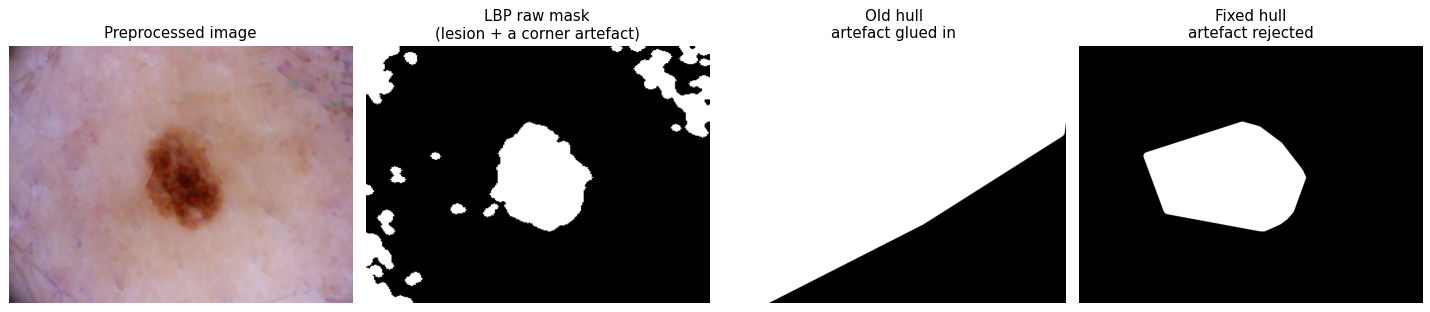

In [11]:
from skimage.measure import label, regionprops
from skimage.morphology import convex_hull_image


def old_smart_hull_with_size_exemption(mask, distance_fraction=0.25, area_ratio=0.03):
    """smart_convex_hull with the size exemption, before it was removed."""
    labelled = label(mask)
    regions = regionprops(labelled)
    main = max(regions, key=lambda region: region.area)
    main_centroid = np.array(main.centroid)
    reach = np.hypot(*mask.shape) * distance_fraction

    kept = labelled == main.label
    for region in regions:
        if region.label == main.label:
            continue
        large_enough = region.area / main.area > area_ratio
        close_enough = np.linalg.norm(np.array(region.centroid) - main_centroid) < reach
        if large_enough or close_enough:  # the bug: size alone was enough
            kept |= labelled == region.label
    return convex_hull_image(kept).astype(np.uint8)


artefact_sample = load_sample(ROOT / "data" / "nevus" / "ISIC_0000095.jpg")
artefact_image, artefact_valid = preprocess_with_mask(artefact_sample.image)
artefact_result = lbp.segment(artefact_image, sigma=3.0, valid_mask=artefact_valid)
artefact_final = postprocessing.clean_mask(artefact_result.mask, artefact_valid)
artefact_final = np.asarray(artefact_final)
from scipy.ndimage import binary_fill_holes

artefact_final = binary_fill_holes(artefact_final).astype(np.uint8)

old_hull = old_smart_hull_with_size_exemption(artefact_final)
new_hull = postprocessing.smart_convex_hull(artefact_final)

from dermoseg.metrics import dice_score

print(f"{artefact_sample.name}: LBP raw mask, {artefact_final.mean():.1%} of the image")
print(f"old hull (size exemption) Dice: {dice_score(old_hull, artefact_sample.ground_truth):.3f}")
print(f"fixed hull (distance only) Dice: {dice_score(new_hull, artefact_sample.ground_truth):.3f}")

figure, axes = plt.subplots(1, 4, figsize=(16, 4.5))
axes[0].imshow(artefact_image)
axes[0].set_title("Preprocessed image")
axes[1].imshow(artefact_final, cmap="gray")
axes[1].set_title("LBP raw mask\n(lesion + a corner artefact)")
axes[2].imshow(old_hull, cmap="gray")
axes[2].set_title("Old hull\nartefact glued in")
axes[3].imshow(new_hull, cmap="gray")
axes[3].set_title("Fixed hull\nartefact rejected")
for axis in axes:
    axis.axis("off")
figure.tight_layout()
plt.show()

## 8. Results over the whole dataset

The table below is produced by `scripts/run_benchmark.py`, which runs the same
`run_all_methods` used above over all twenty images, with every fix
from Section 7. LBP and SRM are seeded and reproduce exactly on re-running.
Otsu's Chan-Vese refinement has a small non-determinism of its own (a handful
of boundary pixels can flip between runs), moving its Dice by up to about
0.0002, never enough to change a number at the precision reported here.

In [12]:
results = pd.read_csv(ROOT / "reports" / "per_image_results.csv")
columns = [name for method in METHODS for name in (method, f"{method}_Hull")]

print("Mean Dice per category")
print(results.groupby("Category")[columns].mean().round(3).to_string())
print("\nMean Dice overall")
print(results[columns].mean().round(3).to_string())

Mean Dice per category
           Otsu  Otsu_Hull    LBP  LBP_Hull   SRM  SRM_Hull
Category                                                   
melanoma  0.815      0.872  0.842     0.895  0.79     0.849
nevus     0.849      0.902  0.841     0.908  0.85     0.888

Mean Dice overall
Otsu         0.832
Otsu_Hull    0.887
LBP          0.841
LBP_Hull     0.901
SRM          0.820
SRM_Hull     0.869


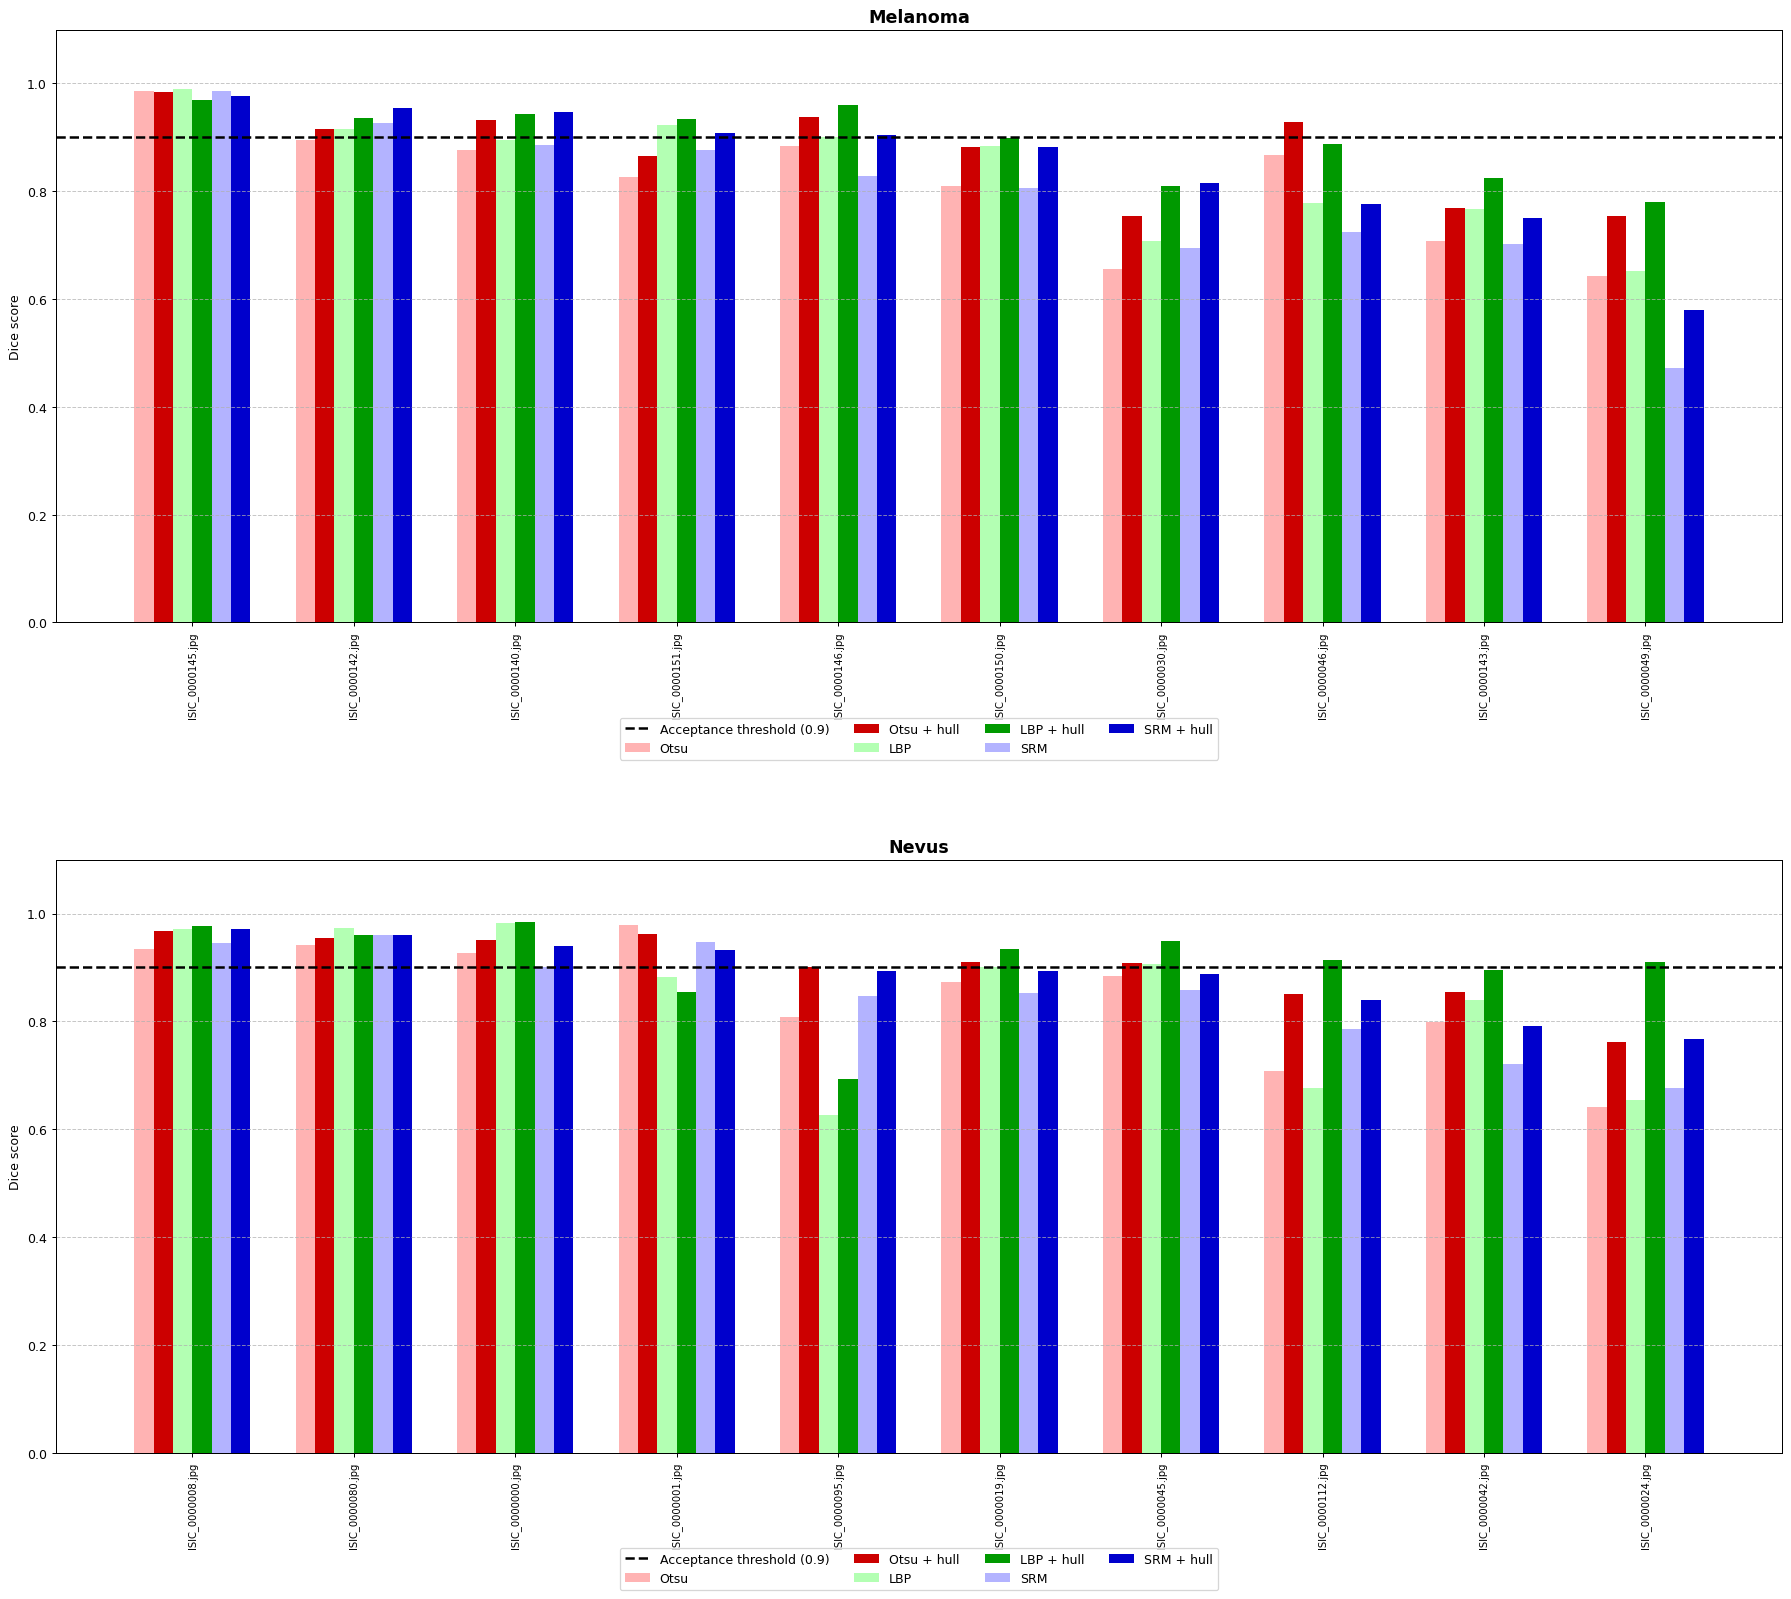

In [13]:
figure, axes = plt.subplots(2, 1, figsize=(20, 18))
viz.plot_dice_per_image(results[results.Category == "melanoma"], "Melanoma", axes[0])
viz.plot_dice_per_image(results[results.Category == "nevus"], "Nevus", axes[1])
figure.tight_layout()
figure.subplots_adjust(bottom=0.1, hspace=0.4)
plt.show()

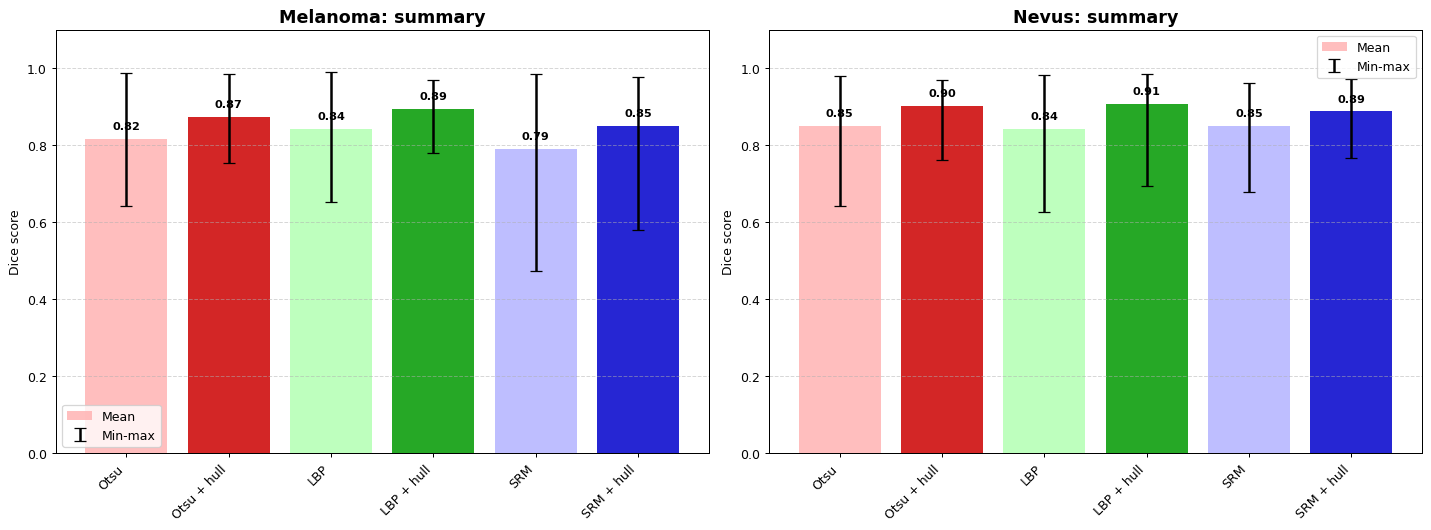

In [14]:
figure, axes = plt.subplots(1, 2, figsize=(16, 6))
viz.plot_summary_stats(results[results.Category == "melanoma"], "Melanoma: summary", axes[0])
viz.plot_summary_stats(results[results.Category == "nevus"], "Nevus: summary", axes[1])
figure.tight_layout()
plt.show()

## 9. What the numbers say

**LBP Clustering gives the best raw masks** (mean Dice 0.841), narrowly ahead
of Otsu (0.832) and SRM (0.820). **With the convex hull, LBP is also the best
overall (0.901)**, ahead of Otsu+hull (0.887) and SRM+hull (0.869). On twenty
images these gaps are small, so the ranking is indicative, not definitive.

**The convex hull helps all three methods by a similar amount**, about +0.049
to +0.060 Dice on average. It is not a free lunch everywhere: it lowers LBP's
score on three images (ISIC_0000001, ISIC_0000145 and ISIC_0000080), by up to
0.027.

**Melanoma against nevus shows no reliable difference here.** Melanomas score
lower on average in five of the six columns, the clinically expected
direction, but with ten images per class none of the gaps is statistically
significant (Mann-Whitney p above 0.4 in every column), and LBP's raw masks
score the same on both.

**The failures are informative.** ISIC_0000024 and ISIC_0000049 drag every
method's raw mask down (all under 0.70). The hull recovers that unevenly:
LBP climbs back to 0.78-0.91, Otsu to the mid-0.70s, and SRM as low as 0.58.
ISIC_0000024 is a low-contrast lesion. ISIC_0000049 is also the largest lesion
in the set, and every method captures only part of it; which of the two
explains its failure is not established here.